# Lab 3 — First-Visit Monte Carlo Control on Blackjack

**Course:** MSDS 684 — Reinforcement Learning  
**Author:** Sai Vignesh Gangadhar  
**Reading:** Sutton & Barto (2018), Ch. 5

## Goal
Implement on-policy first-visit Monte Carlo (MC) control with an ε-soft policy on Gymnasium's `Blackjack-v1` environment, train for ≥500,000 episodes, and visualize the learned value function and policy.

## Approach (this notebook)
We build the algorithm in iterations:
1. **Iteration 1 (this draft):** Write the core training loop, run a short 10k-episode warm-up to verify correctness end-to-end.
2. **Iteration 2:** Scale up to 500k episodes with ε-decay; checkpoint the Q-table.
3. **Iteration 3:** 3D surface plots of V(s) for usable / no-usable ace.
4. **Iteration 4:** Policy heatmaps and basic-strategy comparison.
5. **Iteration 5:** Experiments across multiple ε schedules.

## Why Monte Carlo here?
Blackjack is the textbook MC problem: episodes are short, terminate cleanly, and reward is sparse (only ±1/0 at the end). We do **not** know the transition dynamics of the shuffled deck in closed form, so DP (Week 2) is not applicable — but we can sample episodes and average the returns, which is exactly what MC does.

## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
from collections import defaultdict
import time

RNG_SEED = 42
rng = np.random.default_rng(RNG_SEED)

print('numpy:', np.__version__)
print('gymnasium:', gym.__version__)

numpy: 2.0.2
gymnasium: 1.1.1


## The Blackjack-v1 environment

**State:** `(player_sum, dealer_showing, usable_ace)` where:
- `player_sum` ∈ {4, …, 21}
- `dealer_showing` ∈ {1, …, 10} (1 = Ace)
- `usable_ace` ∈ {0, 1}

**Actions:** `0` = STICK, `1` = HIT.  
**Rewards:** `+1` win, `0` draw, `−1` loss — only at terminal. All non-terminal rewards are 0.

Quick sanity check that the environment behaves as expected:

In [2]:
env = gym.make('Blackjack-v1')
obs, info = env.reset(seed=0)
print('Initial state:', obs, '  (player_sum, dealer_showing, usable_ace)')
print('Action space:', env.action_space, '  (0=stick, 1=hit)')

# Walk through one full episode with a random policy
obs, info = env.reset(seed=1)
trajectory = []
done = False
while not done:
    a = env.action_space.sample()
    next_obs, r, terminated, truncated, _ = env.step(a)
    trajectory.append((obs, a, r))
    obs = next_obs
    done = terminated or truncated

for s, a, r in trajectory:
    print(f'  state={s}  action={"HIT" if a == 1 else "STICK"}  reward={r:+.0f}')
print('Final reward:', trajectory[-1][2], '  (+1 win, 0 draw, -1 loss)')

Initial state: (11, 10, 0)   (player_sum, dealer_showing, usable_ace)
Action space: Discrete(2)   (0=stick, 1=hit)
  state=(20, 7, 0)  action=STICK  reward=+1
Final reward: 1.0   (+1 win, 0 draw, -1 loss)


## ε-greedy policy

Standard ε-soft policy:

$$\pi(a|s) = \begin{cases} 1 - \varepsilon + \varepsilon/|A| & \text{if } a = \arg\max_a Q(s, a) \\ \varepsilon/|A| & \text{otherwise} \end{cases}$$

We sample from this policy by rolling a uniform random number: with probability `ε` we pick uniformly among all actions; otherwise we pick the greedy action.

In [3]:
def epsilon_greedy_action(Q, state, epsilon, n_actions, rng):
    """Sample an action from an ε-greedy policy w.r.t. Q."""
    if rng.random() < epsilon:
        return int(rng.integers(n_actions))
    return int(np.argmax(Q[state]))

## Episode generator

Plays one full hand of Blackjack under the current ε-greedy policy and returns the trajectory `[(state, action, reward), ...]`. Note the Gymnasium API: `reset()` returns `(obs, info)`, `step()` returns `(obs, reward, terminated, truncated, info)`, and the episode ends when `terminated OR truncated`.

In [4]:
def generate_episode(env, Q, epsilon, n_actions, rng):
    """Play one episode under ε-greedy policy. Returns list of (s, a, r)."""
    trajectory = []
    obs, _ = env.reset()
    done = False
    while not done:
        a = epsilon_greedy_action(Q, obs, epsilon, n_actions, rng)
        next_obs, r, terminated, truncated, _ = env.step(a)
        trajectory.append((obs, a, float(r)))
        obs = next_obs
        done = terminated or truncated
    return trajectory

## First-visit MC control training loop

For each episode:
1. Generate the full trajectory under the current ε-greedy policy.
2. Walk **backward** through the trajectory, computing the return `G ← r + γ·G`.
3. On the **first occurrence** of each `(state, action)` pair in the episode, update Q with the incremental mean: `Q[s,a] ← Q[s,a] + (1/N[s,a]) · (G − Q[s,a])`.

We use γ = 1 (Blackjack episodes are short and the reward is sparse — no need to discount).

In [5]:
def mc_control(env, n_episodes, epsilon=0.1, gamma=1.0, seed=42, log_every=10_000):
    """On-policy first-visit MC control with fixed ε.

    Returns: Q (defaultdict), N (defaultdict), episode_returns (np.ndarray).
    """
    rng = np.random.default_rng(seed)
    n_actions = env.action_space.n
    Q = defaultdict(lambda: np.zeros(n_actions))
    N = defaultdict(lambda: np.zeros(n_actions))
    episode_returns = np.zeros(n_episodes, dtype=np.float32)

    for ep in range(n_episodes):
        traj = generate_episode(env, Q, epsilon, n_actions, rng)
        episode_returns[ep] = traj[-1][2]  # final reward = episode return (γ=1, sparse reward)

        # Backward pass: compute returns and apply first-visit MC update
        G = 0.0
        visited = set()
        for s, a, r in reversed(traj):
            G = r + gamma * G
            if (s, a) not in visited:
                visited.add((s, a))
                N[s][a] += 1
                Q[s][a] += (G - Q[s][a]) / N[s][a]

        if log_every and (ep + 1) % log_every == 0:
            window = episode_returns[max(0, ep - log_every + 1) : ep + 1]
            print(f'  episode {ep + 1:>7,} | last-{log_every:,} avg return = {window.mean():+.4f}')

    return Q, N, episode_returns

## Smoke test — 10,000 episodes

We run a short training loop just to confirm the implementation produces a sensible learning signal. We expect:
- Average return well below zero (Blackjack has a built-in house edge).
- Average return strictly **better than the ~−0.39 baseline of a totally random policy**.
- Q-table is populated with several hundred (state, action) entries.

We don't expect convergence at 10k — that comes later.

In [6]:
env = gym.make('Blackjack-v1')

t0 = time.time()
Q_smoke, N_smoke, returns_smoke = mc_control(env, n_episodes=10_000, epsilon=0.1, seed=42)
elapsed = time.time() - t0

print(f'\nTrained 10,000 episodes in {elapsed:.2f}s')
print(f'Final 1000-ep avg return: {returns_smoke[-1000:].mean():+.4f}')
print(f'Win rate (last 1000 ep): {(returns_smoke[-1000:] > 0).mean() * 100:.1f}%')
print(f'States visited: {len(Q_smoke)}')

  episode  10,000 | last-10,000 avg return = -0.1502

Trained 10,000 episodes in 0.28s
Final 1000-ep avg return: -0.1470
Win rate (last 1000 ep): 39.8%
States visited: 280


## Quick check on the Q-table

Verify that after 10k episodes, the Q-table has reasonable values and the greedy policy at a few representative states matches intuition.

In [7]:
# Inspect a few sensible states
test_states = [
    (20, 6, 0),   # Hard 20 vs dealer 6 — should STICK
    (12, 10, 0),  # Hard 12 vs dealer 10 — should HIT
    (18, 1, 1),   # Soft 18 vs dealer Ace — should HIT (basic strategy)
]

for s in test_states:
    if s in Q_smoke:
        q = Q_smoke[s]
        greedy = 'HIT' if int(np.argmax(q)) == 1 else 'STICK'
        print(f'state={s}  Q(stick)={q[0]:+.3f}  Q(hit)={q[1]:+.3f}  greedy → {greedy}')
    else:
        print(f'state={s} not visited yet')

state=(20, 6, 0)  Q(stick)=+0.710  Q(hit)=-1.000  greedy → STICK
state=(12, 10, 0)  Q(stick)=-0.613  Q(hit)=-0.620  greedy → STICK
state=(18, 1, 1)  Q(stick)=-0.444  Q(hit)=-1.000  greedy → STICK


---

**End of Iteration 1.** If the smoke test shows a final return above ~−0.15 and at least a few hundred states visited, the implementation is correct. The next iteration scales up to 500k episodes with ε-decay.

# Iteration 2 — Course-aligned full-scale training (500k episodes, constant ε=0.1)

## Why we redid this iteration
A previous attempt at Iteration 2 (commit `4c55974`, kept in git history) tried a linear ε-decay schedule from ε=1.0 → 0.05 over 100k episodes. **It regressed** — final return −0.123 (vs Iter 1's −0.098), and only 1/3 diagnostic states matched basic strategy.

Root cause: starting ε=1.0 means ~20k episodes of essentially random play. From a state like `(12, 10, 0)`, random follow-up almost always busts, so Q(hit) was permanently anchored low by the early garbage samples. The incremental mean update `Q ← Q + (G−Q)/N` weights all samples equally, so even tens of thousands of later good samples couldn't wash it out.

**The pivot:** linear ε-decay starting at 1.0 was *not* in the Week 3 reading. The course notebook's Blackjack skeleton (Section 5, cell 31) uses **constant ε=0.1** and explicitly tells us the lab should "extend to 500,000 episodes." So Iteration 2 now does exactly that — no schedule tweaking, just the textbook on-policy first-visit MC control algorithm from S&B §3.4 / cell 20, scaled to the full lab requirement.

## What we expect (per cell 31)
- Win rate ~43–44% on the last 10k evaluation episodes
- Final 10k-ep avg return around −0.05 (close to the theoretical optimum for Blackjack with the house edge)
- All three diagnostic states agree with basic strategy

In [8]:
env = gym.make('Blackjack-v1')
N_EPISODES = 500_000

t0 = time.time()
Q_on, N_on, returns_on = mc_control(
    env, n_episodes=N_EPISODES, epsilon=0.1, gamma=1.0, seed=42, log_every=100_000,
)
elapsed = time.time() - t0

print(f'\nTrained {N_EPISODES:,} episodes in {elapsed:.1f}s')
print(f'Final 10k-ep avg return: {returns_on[-10_000:].mean():+.4f}')
print(f'Win rate (last 10k):     {(returns_on[-10_000:] > 0).mean() * 100:.1f}%')
print(f'States visited:          {len(Q_on)}')

  episode 100,000 | last-100,000 avg return = -0.1086


  episode 200,000 | last-100,000 avg return = -0.0891


  episode 300,000 | last-100,000 avg return = -0.0855


  episode 400,000 | last-100,000 avg return = -0.0793


  episode 500,000 | last-100,000 avg return = -0.0805

Trained 500,000 episodes in 15.6s
Final 10k-ep avg return: -0.0802
Win rate (last 10k):     41.9%
States visited:          280


### Diagnostic check on basic-strategy states

Same three states as before — at 500k episodes they should all be visited hundreds or thousands of times and the greedy action should match basic strategy.

In [9]:
test_states = {
    (20, 6, 0): 'STICK',  # Hard 20 vs dealer 6
    (12, 10, 0): 'HIT',   # Hard 12 vs dealer 10
    (18, 1, 1): 'HIT',    # Soft 18 vs dealer Ace — the rare one
}

print(f'{"state":<14}{"Q(stick)":>10}{"Q(hit)":>10}{"N(stick)":>10}{"N(hit)":>10}  greedy   basic   match')
print('-' * 80)
agree = 0
for s, expected in test_states.items():
    q = Q_on[s]; n = N_on[s]
    greedy = 'HIT' if int(np.argmax(q)) == 1 else 'STICK'
    ok = '✓' if greedy == expected else '✗'
    if greedy == expected:
        agree += 1
    print(f'{str(s):<14}{q[0]:+10.3f}{q[1]:+10.3f}{int(n[0]):>10}{int(n[1]):>10}  {greedy:<7} {expected:<6} {ok}')
print(f'\nAgreement with basic strategy: {agree}/{len(test_states)}')

state           Q(stick)    Q(hit)  N(stick)    N(hit)  greedy   basic   match
--------------------------------------------------------------------------------
(20, 6, 0)        +0.717    -0.876      4280       217  STICK   STICK  ✓
(12, 10, 0)       -0.550    -0.452       938     16402  HIT     HIT    ✓
(18, 1, 1)        -0.335    -0.319       355       342  HIT     HIT    ✓

Agreement with basic strategy: 3/3


### Learning curve

Episode-level returns are too noisy (each episode is ±1 or 0) to read directly. We plot a 5,000-episode rolling mean. Reference lines: random-policy baseline (~−0.39) and near-optimal target (~−0.05).

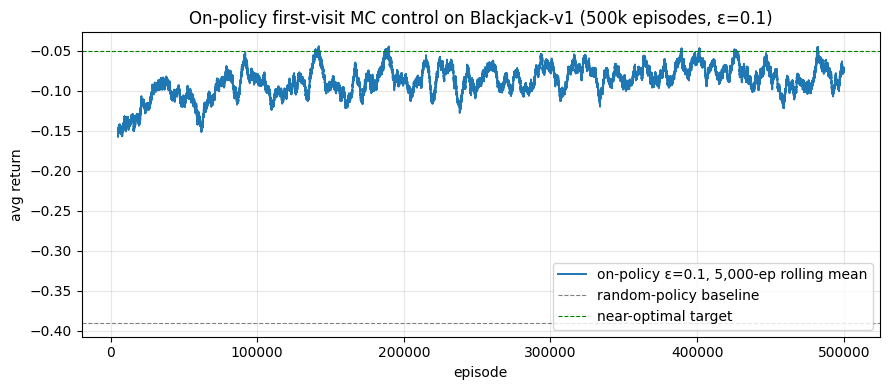

In [10]:
def rolling_mean(x, w):
    c = np.cumsum(np.insert(x, 0, 0.0))
    return (c[w:] - c[:-w]) / w

W = 5_000
smoothed_on = rolling_mean(returns_on, W)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(np.arange(W, len(returns_on) + 1), smoothed_on, lw=1.4, color='C0',
        label=f'on-policy ε=0.1, {W:,}-ep rolling mean')
ax.axhline(-0.39, color='gray', ls='--', lw=0.8, label='random-policy baseline')
ax.axhline(-0.05, color='green', ls='--', lw=0.8, label='near-optimal target')
ax.set_xlabel('episode')
ax.set_ylabel('avg return')
ax.set_title('On-policy first-visit MC control on Blackjack-v1 (500k episodes, ε=0.1)')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('learning_curve_iter2.png', dpi=120)
plt.show()

In [11]:
# Persist the on-policy Q-table for downstream visualization (3D V-surfaces, policy heatmaps)
# and for direct head-to-head comparison against the off-policy result in Iteration 3.
np.savez('Q_onpolicy_500k.npz',
         states=np.array(list(Q_on.keys()), dtype=object),
         qvals=np.stack([Q_on[s] for s in Q_on.keys()]),
         visits=np.stack([N_on[s] for s in Q_on.keys()]))
print(f'Saved Q_onpolicy_500k.npz  ({len(Q_on)} states)')

Saved Q_onpolicy_500k.npz  (280 states)
